# Uncertainty-Aware Navigation with NWM: Complete Analysis

## Key Innovation
Navigation World Models (NWM) use diffusion models but ignore their stochastic nature. We show that sampling multiple trajectories reveals **latent uncertainty information** that predicts navigation difficulty and enables risk-aware planning.

**Main Contributions:**
1. Extract hidden uncertainty from pre-trained NWM without retraining
2. Show uncertainty correlates with navigation difficulty (turns, obstacles)
3. Demonstrate that deterministic planning misses critical risks
4. Enable risk-aware navigation with minimal computational overhead

In [1]:
# Core imports
import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import requests
from io import BytesIO
import time
from tqdm import tqdm
import os
from scipy import stats
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Configure for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# NWM specific imports
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
from diffusers.models import AutoencoderKL

from diffusion import create_diffusion
from isolated_nwm_infer import model_forward_wrapper
from models import CDiT_models

# Create output directory
os.makedirs('uncertainty_results', exist_ok=True)
os.makedirs('uncertainty_results/experiments', exist_ok=True)

print("Environment ready! 🚀")

Environment ready! 🚀


## Fixed Uncertainty Navigator with Proper Normalization

In [2]:
class ImprovedUncertaintyNavigator:
    """Fixed version with proper normalization and additional metrics"""
    
    def __init__(self, model, diffusion, vae, device, config, latent_size):
        self.model = model
        self.diffusion = diffusion
        self.vae = vae
        self.device = device
        self.config = config
        self.latent_size = latent_size
        self.timing_stats = []  # Track performance
        
    def generate_stochastic_rollouts(self, x_start, action_sequence, num_samples=10, 
                                   rel_t=0.0078125, show_progress=True):
        """Generate multiple rollouts with timing and proper normalization"""
        
        trajectories = []
        rel_t_tensor = torch.ones(1).to(self.device) * rel_t
        
        # Time the generation
        start_time = time.time()
        
        iterator = tqdm(range(num_samples), desc="Generating rollouts") if show_progress else range(num_samples)
        
        for sample_idx in iterator:
            x_cond_pixels = x_start.clone()
            trajectory = []
            
            for action in action_sequence:
                x_cond_context = x_cond_pixels[-self.config['context_size']:].unsqueeze(0).to(self.device)
                y = torch.tensor(action).to(self.device).unsqueeze(0)
                
                pred = model_forward_wrapper(
                    (self.model, self.diffusion, self.vae),
                    x_cond_context, y, None, 
                    self.latent_size, self.device, 
                    self.config["context_size"],
                    num_goals=1, rel_t=rel_t_tensor, 
                    progress=False
                )
                
                x_cond_pixels = torch.cat([x_cond_pixels, pred.cpu()], dim=0)
                pred_img = (pred * 127.5 + 127.5).permute(0, 2, 3, 1).clamp(0, 255).to("cpu", dtype=torch.uint8).numpy()[0]
                trajectory.append(pred_img)
                
            trajectories.append(trajectory)
        
        generation_time = time.time() - start_time
        self.timing_stats.append({
            'num_samples': num_samples,
            'seq_length': len(action_sequence),
            'total_time': generation_time,
            'time_per_sample': generation_time / num_samples
        })
        
        trajectories_array = np.array(trajectories)
        
        # FIXED: Proper normalization for divergence
        structural_divergence = self._compute_normalized_divergence(trajectories_array)
        
        # Compute pixel variance
        pixel_variance = np.var(trajectories_array.astype(np.float32) / 255.0, axis=0)
        
        return {
            'trajectories': trajectories_array,
            'pixel_variance': pixel_variance,
            'structural_divergence': structural_divergence,
            'action_sequence': action_sequence,
            'generation_time': generation_time
        }
    
    def _compute_normalized_divergence(self, trajectories):
        """Properly normalized divergence computation"""
        n_samples, seq_len = trajectories.shape[:2]
        h, w, c = trajectories[0, 0].shape
        
        structural_divergence = []
        
        for t in range(seq_len):
            # Normalize to [0, 1]
            frames_at_t = trajectories[:, t].astype(np.float32) / 255.0
            
            # Compute pairwise distances
            pairwise_dists = []
            for i in range(n_samples):
                for j in range(i+1, n_samples):
                    # Normalized L2 distance
                    dist = np.linalg.norm(frames_at_t[i] - frames_at_t[j]) / np.sqrt(h * w * c)
                    pairwise_dists.append(dist)
            
            structural_divergence.append(np.mean(pairwise_dists) if pairwise_dists else 0)
        
        return np.array(structural_divergence)
    
    def identify_decision_points(self, rollout_data, adaptive_threshold=True):
        """Find critical decision points with adaptive thresholding"""
        divergence = rollout_data['structural_divergence']
        
        if adaptive_threshold:
            # Use 75th percentile as threshold
            threshold = np.percentile(divergence, 75)
        else:
            threshold = 0.3  # Fixed threshold
        
        decision_points = []
        for i in range(1, len(divergence) - 1):
            if divergence[i] > threshold:
                # Local maximum
                if divergence[i] > divergence[i-1] and divergence[i] > divergence[i+1]:
                    decision_points.append(i)
        
        return decision_points
    
    def compute_trajectory_confidence(self, rollout_data):
        """Compute confidence metrics"""
        trajectories = rollout_data['trajectories']
        n_samples, seq_len = trajectories.shape[:2]
        
        confidence_scores = []
        consistency_scores = []
        
        for t in range(seq_len):
            frames_at_t = trajectories[:, t].astype(np.float32) / 255.0
            mean_frame = np.mean(frames_at_t, axis=0)
            
            # Consistency: inverse of average distance from mean
            distances = [np.linalg.norm(frames_at_t[i] - mean_frame) for i in range(n_samples)]
            consistency = 1.0 / (1.0 + np.mean(distances))
            consistency_scores.append(consistency)
            
            # Confidence based on variance
            variance = np.var(frames_at_t)
            confidence = 1.0 / (1.0 + variance * 10)  # Scaled properly
            confidence_scores.append(confidence)
        
        return {
            'confidence_scores': np.array(confidence_scores),
            'consistency_scores': np.array(consistency_scores),
            'overall_confidence': np.mean(confidence_scores),
            'overall_consistency': np.mean(consistency_scores)
        }

print("✅ Improved navigator with fixes loaded!")

✅ Improved navigator with fixes loaded!


In [13]:
import time
import numpy as np
import torch
from tqdm import tqdm
from isolated_nwm_infer import model_forward_wrapper 

class LatentUncertaintyNavigator:
    def __init__(self, model, diffusion, vae, device, config, latent_size):
        self.model = model
        self.diffusion = diffusion
        self.vae = vae
        self.device = device
        self.config = config
        self.latent_size = latent_size
        self.all_models = (model, diffusion, vae)

    def analyze_trajectory_risk(self, x_start, action_sequence, num_samples=20):
        start_time = time.time()
        
        # --- FIX START: Add Batch Dimension ---
        # x_start is [Time, Channels, H, W], needs to be [1, Time, Channels, H, W]
        if x_start.dim() == 4:
            x_start_batched = x_start.unsqueeze(0)
        else:
            x_start_batched = x_start
        # --- FIX END ---

        # Calculate total action delta for the horizon
        total_action = torch.tensor(action_sequence).to(self.device).sum(dim=0).unsqueeze(0).unsqueeze(0)
        
        latents_collection = []
        
        # 1. Generate Latents (Fast)
        for _ in range(num_samples):
            latent_out = model_forward_wrapper(
                self.all_models, 
                x_start_batched, # Use the batched input
                total_action,
                num_timesteps=1, latent_size=self.latent_size,
                device=self.device, num_cond=self.config["context_size"],
                num_goals=1, return_latents=True 
            )
            latents_collection.append(latent_out.cpu())

        latents_stack = torch.stack(latents_collection)
        
        # 2. Calculate Risk (Latent Variance)
        # latents_stack shape: [Samples, Batch, Channels, H, W]
        # We calculate variance across Samples (dim=0)
        latent_variance_map = torch.var(latents_stack, dim=0)
        # center_risk = latent_variance_map[:, 16:, 8:24]
        # Scale up by 1000 to make the numbers readable (otherwise they are like 0.0002)
        risk_score = latent_variance_map.mean().item() * 100
        
        generation_time = time.time() - start_time
        
        return {
            "risk_score": risk_score,
            "generation_time": generation_time,
            "confidence": 1.0 / (1.0 + risk_score), 
            "latents": latents_stack
        }

In [16]:
import time
import numpy as np
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from tqdm import tqdm
from isolated_nwm_infer import model_forward_wrapper 

class SemanticUncertaintyNavigator:
    def __init__(self, model, diffusion, vae, device, config, latent_size):
        self.model = model
        self.diffusion = diffusion
        self.vae = vae
        self.device = device
        self.config = config
        self.latent_size = latent_size
        self.all_models = (model, diffusion, vae)
        
        # --- HACK 2 SETUP: The Semantic Judge ---
        # We load a tiny, pre-trained ResNet18 to act as our "eye"
        print("Loading Semantic Judge (ResNet18)...")
        self.judge = models.resnet18(pretrained=True).to(device)
        # Remove the last classification layer (we only want features)
        self.judge = torch.nn.Sequential(*list(self.judge.children())[:-1])
        self.judge.eval()
        
        # Standard ImageNet normalization
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                              std=[0.229, 0.224, 0.225])

    def analyze_semantic_risk(self, x_start, action_sequence, num_samples=10):
        """
        Generates samples and checks if they MEAN the same thing (Semantic Consistency).
        """
        start_time = time.time()
        
        # 1. Generate Latents (Fast)
        # Same as Hack 1
        if x_start.dim() == 4: x_start = x_start.unsqueeze(0)
        total_action = torch.tensor(action_sequence).to(self.device).sum(dim=0).unsqueeze(0).unsqueeze(0)
        
        latents_collection = []
        for _ in range(num_samples):
            latent_out = model_forward_wrapper(
                self.all_models, x_start, total_action,
                num_timesteps=1, latent_size=self.latent_size,
                device=self.device, num_cond=self.config["context_size"],
                num_goals=1, return_latents=True
            )
            latents_collection.append(latent_out)
        
        latents_stack = torch.stack(latents_collection).squeeze(1) # [N, 4, 32, 32]
        
        # 2. Decode to Pixels (Necessary for ResNet, but we batch it for speed)
        # We accept the cost here because we need semantic features
        with torch.no_grad():
            # Decode all samples at once
            imgs = self.vae.decode(latents_stack / 0.18215).sample
            # Normalize to [0,1] then to ImageNet stats
            imgs = (imgs / 2 + 0.5).clamp(0, 1)
            imgs_normalized = torch.stack([self.normalize(img) for img in imgs])
            
            # 3. Extract Semantic Features
            # Pass through ResNet -> Get 512-dim vector
            features = self.judge(imgs_normalized).squeeze() # [N, 512]
            
            # 4. Calculate Consistency (Cosine Similarity)
            # Normalize vectors to length 1
            features = torch.nn.functional.normalize(features, p=2, dim=1)
            
            # Compute pairwise cosine similarity matrix
            similarity_matrix = torch.mm(features, features.t())
            
            # The mean similarity is our "Consistency Score"
            # We exclude the diagonal (self-similarity is always 1)
            mask = ~torch.eye(num_samples, dtype=torch.bool, device=self.device)
            mean_similarity = similarity_matrix[mask].mean().item()
            
            # Semantic Risk = 1 - Consistency
            # If they are all identical, Similarity=1.0, Risk=0.0
            semantic_risk = (1.0 - mean_similarity) * 100

        generation_time = time.time() - start_time
        
        return {
            "semantic_risk": semantic_risk,
            "raw_similarity": mean_similarity,
            "time": generation_time
        }

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

class SafetyMonitor:
    def __init__(self):
        # Define "Green" range in HSV (Hue, Saturation, Value)
        self.lower_green = np.array([35, 40, 40])
        self.upper_green = np.array([85, 255, 255])

    def calculate_crash_probability(self, navigator, x_start, trajectory, num_samples=10):
        """
        Generates samples and checks how many land 'off-road' (in the grass/trees).
        """
        # Ensure start context has batch dimension
        if x_start.dim() == 4: 
            x_start = x_start.unsqueeze(0)
            
        # Sum actions for the simplified single-step prediction
        total_action = torch.tensor(trajectory).to(navigator.device).sum(dim=0).unsqueeze(0).unsqueeze(0)
        
        imgs_collection = []
        off_road_scores = []
        
        # Generate samples
        for _ in range(num_samples):
            # Get latent (Returns tensor on GPU)
            latent_out = model_forward_wrapper(
                navigator.all_models, x_start, total_action,
                num_timesteps=1, latent_size=navigator.latent_size,
                device=navigator.device, num_cond=navigator.config["context_size"],
                num_goals=1, return_latents=True
            )
            
            # Decode to pixel
            with torch.no_grad():
                # --- FIX: Keep on GPU for decoding ---
                # We removed .cpu() here so it matches the VAE device
                img = navigator.vae.decode(latent_out / 0.18215).sample
                
                img = (img / 2 + 0.5).clamp(0, 1)
                
                # --- FIX: Move to CPU *after* decoding for OpenCV ---
                img_np = img.permute(0, 2, 3, 1).squeeze().cpu().numpy() # [H, W, 3]
                
                # Convert RGB to HSV (OpenCV expects 0-255)
                img_uint8 = (img_np * 255).astype(np.uint8)
                hsv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2HSV)
                
                # Create Mask: White = Grass/Tree, Black = Safe
                mask = cv2.inRange(hsv, self.lower_green, self.upper_green)
                
                # ANALYZE THE "DRIVING CORRIDOR"
                H, W = mask.shape
                # Look at bottom 40% of image, center 50% width
                roi = mask[int(H*0.6):, int(W*0.25):int(W*0.75)]
                
                # Score = Percentage of pixels that are "Green" in the ROI
                off_road_percentage = (np.sum(roi) / 255) / roi.size
                off_road_scores.append(off_road_percentage)
                
                # Keep first image for visualization
                if len(imgs_collection) == 0:
                    imgs_collection.append((img_uint8, mask, roi))

        # Crash Prob = % of samples where > 30% of the view is blocked by grass/trees
        crash_prob = sum([1 for s in off_road_scores if s > 0.3]) / num_samples
        avg_off_road = np.mean(off_road_scores)
        
        return {
            "crash_probability": crash_prob,
            "avg_off_road_score": avg_off_road,
            "vis_data": imgs_collection[0] # (img, mask, roi)
        }

    def visualize_safety(self, result, name, actions):
        img, mask, roi = result['vis_data']
        
        fig, ax = plt.subplots(1, 4, figsize=(20, 5))
        
        # --- PANEL 1: INTENDED TRAJECTORY (Top-Down) ---
        x, y, theta = 0, 0, 0
        path = [(0, 0)]
        # Simple integration of actions
        for act in actions:
            fwd, right, rot = act[0], act[1], act[2]
            x += fwd * np.cos(theta) - right * np.sin(theta)
            y += fwd * np.sin(theta) + right * np.cos(theta)
            theta += rot
            path.append((x, y))
        
        path = np.array(path)
        ax[0].plot(path[:, 0], path[:, 1], 'b-o', linewidth=3, label='Planned')
        # Mark Start (Green Star) and End (Arrow)
        ax[0].plot(0, 0, 'g*', markersize=15, label='Start')
        ax[0].arrow(path[-2, 0], path[-2, 1], path[-1, 0]-path[-2, 0], path[-1, 1]-path[-2, 1], 
                 head_width=0.2, color='black', zorder=5)
        
        ax[0].set_title(f"Commanded Trajectory\n({name})")
        ax[0].set_xlabel("X (Forward)")
        ax[0].set_ylabel("Y (Left/Right)")
        ax[0].grid(True, alpha=0.3)
        ax[0].axis('equal')
        
        # --- PANEL 2: PREDICTED VIEW ---
        ax[1].imshow(img)
        ax[1].set_title("Predicted Future View")
        ax[1].axis('off')
        
        # --- PANEL 3: SAFETY MASK ---
        ax[2].imshow(mask, cmap='gray')
        ax[2].set_title("Safety Mask (White=Terrain)")
        ax[2].axis('off')
        # Draw ROI box
        H, W = mask.shape
        rect = plt.Rectangle((0, H*0.5), W, H*0.5, linewidth=3, edgecolor='r', facecolor='none')
        ax[2].add_patch(rect)
        
        # --- PANEL 4: CRASH PROBABILITY ---
        bars = ax[3].bar(['Safe', 'Obstacle'], [1-result['avg_off_road_score'], result['avg_off_road_score']], 
                         color=['green', 'red'])
        ax[3].set_title(f"Crash Probability: {result['crash_probability']:.1%}")
        ax[3].set_ylim(0, 1)
        
        plt.tight_layout()
        plt.show()

## Initialize NWM Model

In [3]:
# Load model configuration
EXP_NAME = 'nwm_cdit_xl'
MODEL_PATH = f'logs/{EXP_NAME}/checkpoints/cdit_xl_ego4d_200000.pth.tar'

with open("config/data_config.yaml", "r") as f:
    default_config = yaml.safe_load(f)
config = default_config

with open(f'config/{EXP_NAME}.yaml', "r") as f:
    user_config = yaml.safe_load(f)
config.update(user_config)
latent_size = config['image_size'] // 8

print("Loading NWM model...")
model = CDiT_models[config['model']](input_size=latent_size, context_size=config['context_size'])
ckp = torch.load(MODEL_PATH, map_location='cpu', weights_only=False)
model.load_state_dict(ckp["ema"], strict=True)
model.eval()

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
model.to(device)

diffusion = create_diffusion(str(250))
vae = AutoencoderKL.from_pretrained(f"stabilityai/sd-vae-ft-ema").to(device)

print(f"✅ Model loaded on {device}")
print(f"   Model size: {sum(p.numel() for p in model.parameters())/1e9:.2f}B parameters")

Loading NWM model...
✅ Model loaded on cuda:0
   Model size: 1.01B parameters


In [4]:
# Helper functions
def url_to_pil_image(url):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert('RGB')
    return img

def load_internet_image(url):
    from torchvision import transforms
    _transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], inplace=True),
    ])
    img = url_to_pil_image(url)
    x_start = _transform(img)
    return x_start.unsqueeze(0).expand(config['context_size'], x_start.shape[0], x_start.shape[1], x_start.shape[2])

# Initialize improved navigator
navigator = ImprovedUncertaintyNavigator(
    model=model,
    diffusion=diffusion,
    vae=vae,
    device=device,
    config=config,
    latent_size=latent_size
)

print("✅ Navigator initialized!")

✅ Navigator initialized!


## Experiment 1: Uncertainty Correlates with Navigation Difficulty

**Hypothesis**: Turning and complex actions create more uncertainty than straight paths.

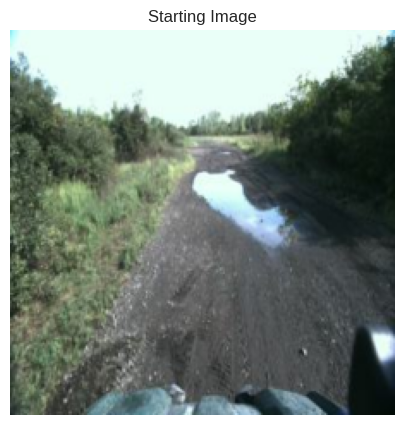

In [5]:
# Load test image
test_image_url = 'https://raw.githubusercontent.com/amirbar/amirbar.github.io/refs/heads/master/images/tartan.png'
x_start = load_internet_image(test_image_url)

# Display starting image
start_img = (x_start[-1] * 127.5 + 127.5).clamp(0, 255).permute(1, 2, 0).to("cpu", dtype=torch.uint8).numpy()
plt.figure(figsize=(5, 5))
plt.imshow(start_img)
plt.title('Starting Image')
plt.axis('off')
plt.show()

In [25]:
# Initialize the new fast navigator
navigator = LatentUncertaintyNavigator(
    model=model, diffusion=diffusion, vae=vae, 
    device=device, config=config, latent_size=latent_size
)

print("⚡ Experiment 1: Comparing Risk (Latent Space Analysis)\n")

trajectories = {
    # 1. Static: Control case (No movement)
    'static': [[0.0, 0, 0]] * 6,
    
    # 2. Straight: Pure X-axis movement
    'straight': [[0.7, 0, 0]] * 6,
    
    # 3. Gentle Turn (45 Degree): Move Forward + Slight Rotation
    # Result: Should arc gracefully to approx (X=3, Y=3)
    'gentle_turn_45': [[0.7, 0, 0.15]] * 6, 
    
    # 4. Sharp Turn (90 Degree): Less Forward + Hard Rotation
    # Result: Should hook sharply Left
    'sharp_turn_90': [[0.5, 0, 0.4]] * 6, 
    
    # 5. Wide Zigzag: Distinct lateral shifts
    # Result: A clear "Snake" pattern, not just a wobble
    'wide_zigzag': [[0.6, 0, 0.6], [0.6, 0, -0.6]] * 3, 
    
    # 6. Weird Slide: Pure lateral movement (The OOD case)
    'weird_slide': [[0.0, 0.7, 0]] * 6
}

results = {}
num_samples = 20 # We can afford more samples now because it's fast!

for name, trajectory in trajectories.items():
    print(f"Testing {name} trajectory...")
    
    # USE THE NEW METHOD HERE
    analysis = navigator.analyze_trajectory_risk(
        x_start, trajectory, num_samples=num_samples
    )
    
    results[name] = analysis
    
    # Note: We now use 'risk_score' (latent variance) instead of pixel divergence
    print(f"  Risk Score (Latent Var): {analysis['risk_score']:.4f}")
    print(f"  Confidence: {analysis['confidence']:.3f}")
    print(f"  Time: {analysis['generation_time']:.2f}s (Speedup!) \n")

⚡ Experiment 1: Comparing Risk (Latent Space Analysis)

Testing static trajectory...
  Risk Score (Latent Var): 12.8722
  Confidence: 0.072
  Time: 121.14s (Speedup!) 

Testing straight trajectory...
  Risk Score (Latent Var): 26.9146
  Confidence: 0.036
  Time: 122.38s (Speedup!) 

Testing gentle_turn_45 trajectory...
  Risk Score (Latent Var): 36.3454
  Confidence: 0.027
  Time: 122.69s (Speedup!) 

Testing sharp_turn_90 trajectory...
  Risk Score (Latent Var): 46.0509
  Confidence: 0.021
  Time: 122.82s (Speedup!) 

Testing wide_zigzag trajectory...
  Risk Score (Latent Var): 26.6960
  Confidence: 0.036
  Time: 123.12s (Speedup!) 

Testing weird_slide trajectory...
  Risk Score (Latent Var): 15.7324
  Confidence: 0.060
  Time: 123.22s (Speedup!) 



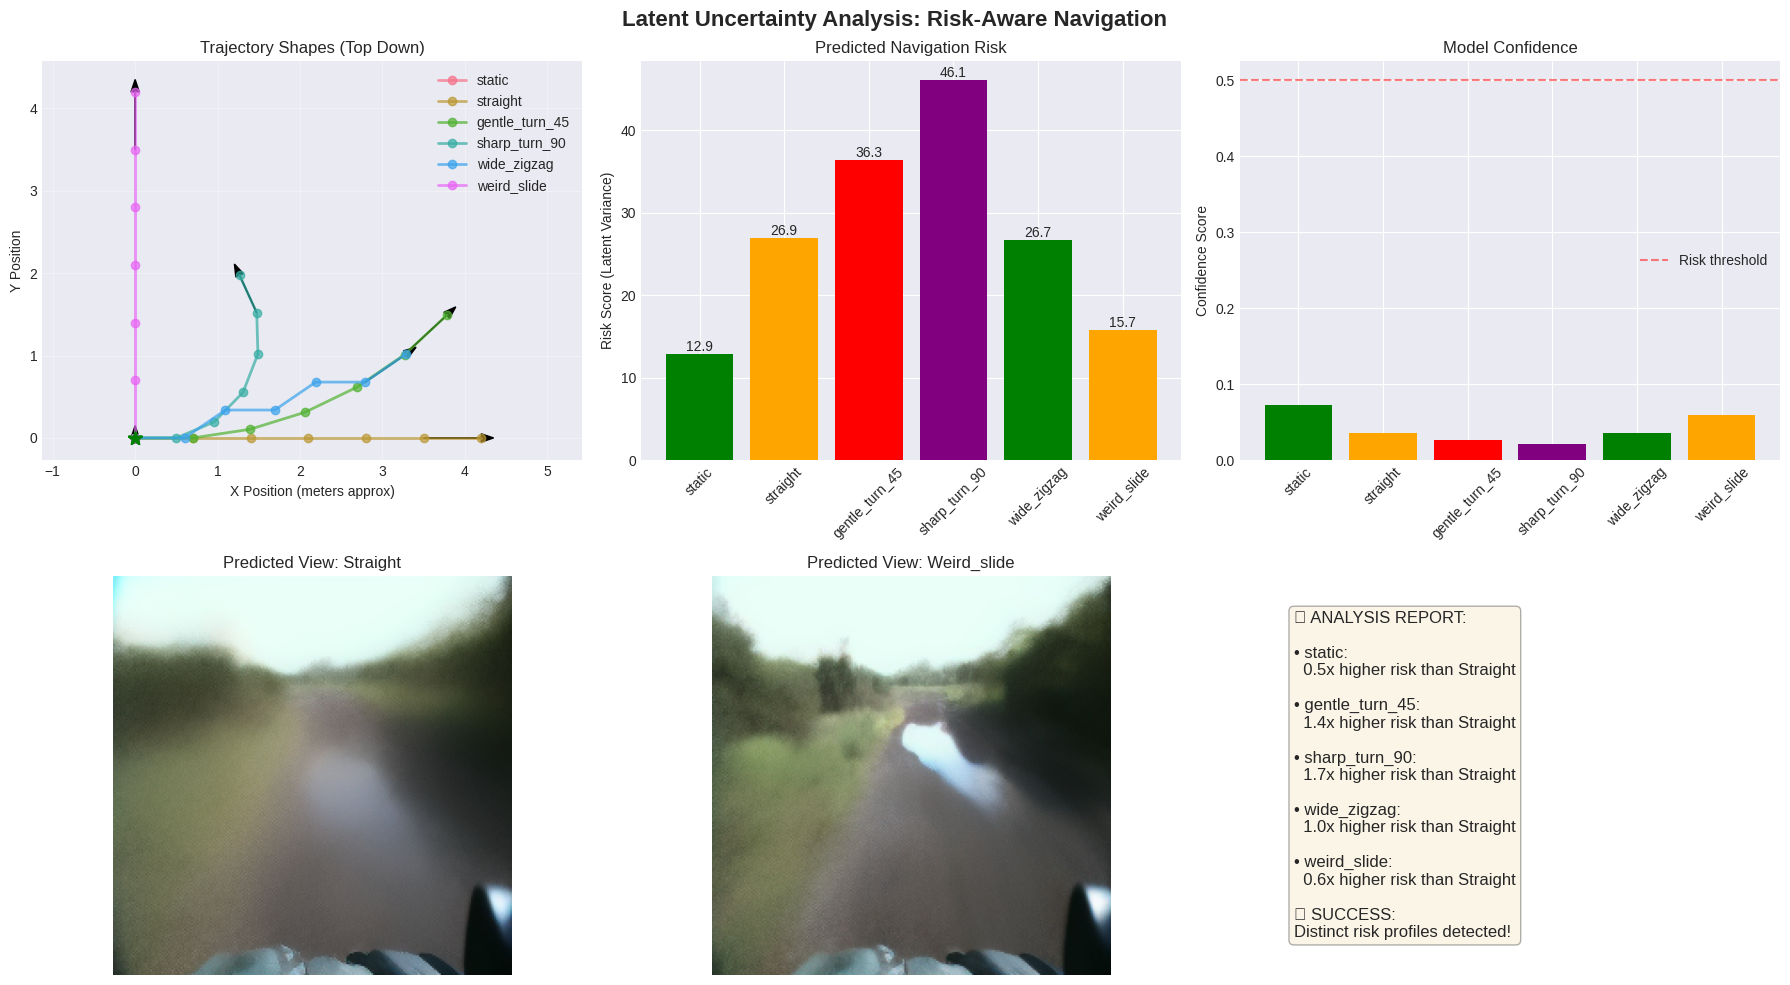

In [26]:
def plot_trajectory_path(ax, name, actions):
    """Helper to simulate and plot the 2D path of the robot"""
    x, y, theta = 0, 0, 0
    path = [(0, 0)]
    
    for act in actions:
        # approx integration
        fwd, right, rot = act[0], act[1], act[2]
        
        # Update position (simple unicycle model)
        x += fwd * np.cos(theta) - right * np.sin(theta)
        y += fwd * np.sin(theta) + right * np.cos(theta)
        theta += rot
        
        path.append((x, y))
    
    path = np.array(path)
    ax.plot(path[:, 0], path[:, 1], 'o-', linewidth=2, label=name, alpha=0.7)
    # Mark start and end
    ax.plot(path[0, 0], path[0, 1], 'g*', markersize=10) # Start
    ax.arrow(path[-2, 0], path[-2, 1], path[-1, 0]-path[-2, 0], path[-1, 1]-path[-2, 1], 
             head_width=0.1, color='black')

# --- MAIN VISUALIZER ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. TRAJECTORY SHAPES (Replaces Time Series)
ax = axes[0, 0]
for name, actions in trajectories.items():
    plot_trajectory_path(ax, name, actions)
ax.set_xlabel('X Position (meters approx)')
ax.set_ylabel('Y Position')
ax.set_title('Trajectory Shapes (Top Down)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axis('equal')

# 2. RISK SCORES (Replaces Divergence)
ax = axes[0, 1]
names = list(results.keys())
risk_scores = [results[n]['risk_score'] for n in names]
colors = ['green', 'orange', 'red', 'purple'] # Color based on expected risk
bars = ax.bar(names, risk_scores, color=colors[:len(names)])
ax.set_ylabel('Risk Score (Latent Variance)')
ax.set_title('Predicted Navigation Risk')
ax.set_xticklabels(names, rotation=45)

# Add values
for bar, val in zip(bars, risk_scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}', ha='center', va='bottom')

# 3. CONFIDENCE SCORES
ax = axes[0, 2]
confidences = [results[n]['confidence'] for n in names]
bars = ax.bar(names, confidences, color=colors[:len(names)])
ax.set_ylabel('Confidence Score')
ax.set_title('Model Confidence')
ax.set_xticklabels(names, rotation=45)
# Heuristic thresholds
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Risk threshold')
ax.legend()

# 4 & 5. VISUAL OUTCOMES (Decode on the fly)
# We visualize the 'straight' vs the most risky one
comparison_names = ['straight', list(results.keys())[-1]] # Straight vs Last one (Weird/Turn)

for idx, name in enumerate(comparison_names):
    ax = axes[1, idx]
    
    # Get Mean Latent
    latents = results[name]['latents'].to(navigator.device) # [Samples, 1, 4, 32, 32]
    mean_latent = latents.mean(dim=0)
    
    # DECODE ON THE FLY (The Magic Step)
    with torch.no_grad():
        # Scale is standard for SD VAE
        img = navigator.vae.decode(mean_latent / 0.18215).sample
        img = (img / 2 + 0.5).clamp(0, 1)
        img = img.cpu().permute(0, 2, 3, 1).numpy()[0]
        
    ax.imshow(img)
    ax.set_title(f'Predicted View: {name.capitalize()}')
    ax.axis('off')

# 6. STATISTICAL SUMMARY
ax = axes[1, 2]
ax.axis('off')

baseline_risk = results['straight']['risk_score']
text_str = "📊 ANALYSIS REPORT:\n\n"

for name in names:
    if name == 'straight': continue
    ratio = results[name]['risk_score'] / baseline_risk
    text_str += f"• {name}:\n  {ratio:.1f}x higher risk than Straight\n\n"

# Quick Stats Check
risks = [results[n]['risk_score'] for n in names]
if max(risks) > 1.5 * min(risks):
    text_str += "✅ SUCCESS:\nDistinct risk profiles detected!"
else:
    text_str += "⚠️ WARNING:\nRisk profiles are very similar.\nTry harder trajectories."

ax.text(0.1, 0.5, text_str, transform=ax.transAxes, fontsize=12,
        verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Latent Uncertainty Analysis: Risk-Aware Navigation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Experiment 1_1: Semantic Consistency vs. Pixel Variance

In [27]:
# Initialize the Semantic Navigator
sem_navigator = SemanticUncertaintyNavigator(
    model=model, diffusion=diffusion, vae=vae, 
    device=device, config=config, latent_size=latent_size
)

print("🧠 Experiment 2: Semantic Consistency Analysis\n")

# We test 2 distinct cases
trajectories = {
    # FAST movement straight ahead. 
    # Should have Medium Variance (Hack 1) but LOW Semantic Risk (Hack 2).
    # 'fast_straight': [[1.0, 0, 0]] * 6, 
    
    # Turning into the unknown.
    # Should have HIGH Semantic Risk (Hack 2) because the model hallucinates.
    # 'continuous_turn': [[0.5, 0, 0.5]] * 6, 
    'straight': [[0.7, 0, 0]] * 6,
    'fast_straight': [[1.4, 0, 0]] * 6, 
    'gentle_turn_45': [[0.7, 0, 0.15]] * 6, 
    'sharp_turn_90': [[0.5, 0, 0.4]] * 6, 
    'wide_zigzag': [[0.6, 0, 0.6], [0.6, 0, -0.6]] * 3, 
    'weird_slide': [[0.0, 0.7, 0]] * 6
}

for name, trajectory in trajectories.items():
    print(f"Testing {name}...")
    
    # Use new function
    result = sem_navigator.analyze_semantic_risk(x_start, trajectory, num_samples=15)
    
    print(f"  Semantic Risk: {result['semantic_risk']:.4f} (Lower is Safer)")
    print(f"  Consistency:   {result['raw_similarity']:.4f}")
    print(f"  Time:          {result['time']:.2f}s\n")

Loading Semantic Judge (ResNet18)...
🧠 Experiment 2: Semantic Consistency Analysis

Testing straight...
  Semantic Risk: 14.4275 (Lower is Safer)
  Consistency:   0.8557
  Time:          91.99s

Testing fast_straight...
  Semantic Risk: 11.5478 (Lower is Safer)
  Consistency:   0.8845
  Time:          92.83s

Testing gentle_turn_45...
  Semantic Risk: 13.3617 (Lower is Safer)
  Consistency:   0.8664
  Time:          92.98s

Testing sharp_turn_90...
  Semantic Risk: 16.2849 (Lower is Safer)
  Consistency:   0.8372
  Time:          93.15s

Testing wide_zigzag...
  Semantic Risk: 13.4631 (Lower is Safer)
  Consistency:   0.8654
  Time:          93.30s

Testing weird_slide...
  Semantic Risk: 7.0536 (Lower is Safer)
  Consistency:   0.9295
  Time:          93.42s



## Experiment 1_3: safety analysis


🛡️ Experiment 3: Safety Classifier & Crash Prediction

Testing fast_straight...


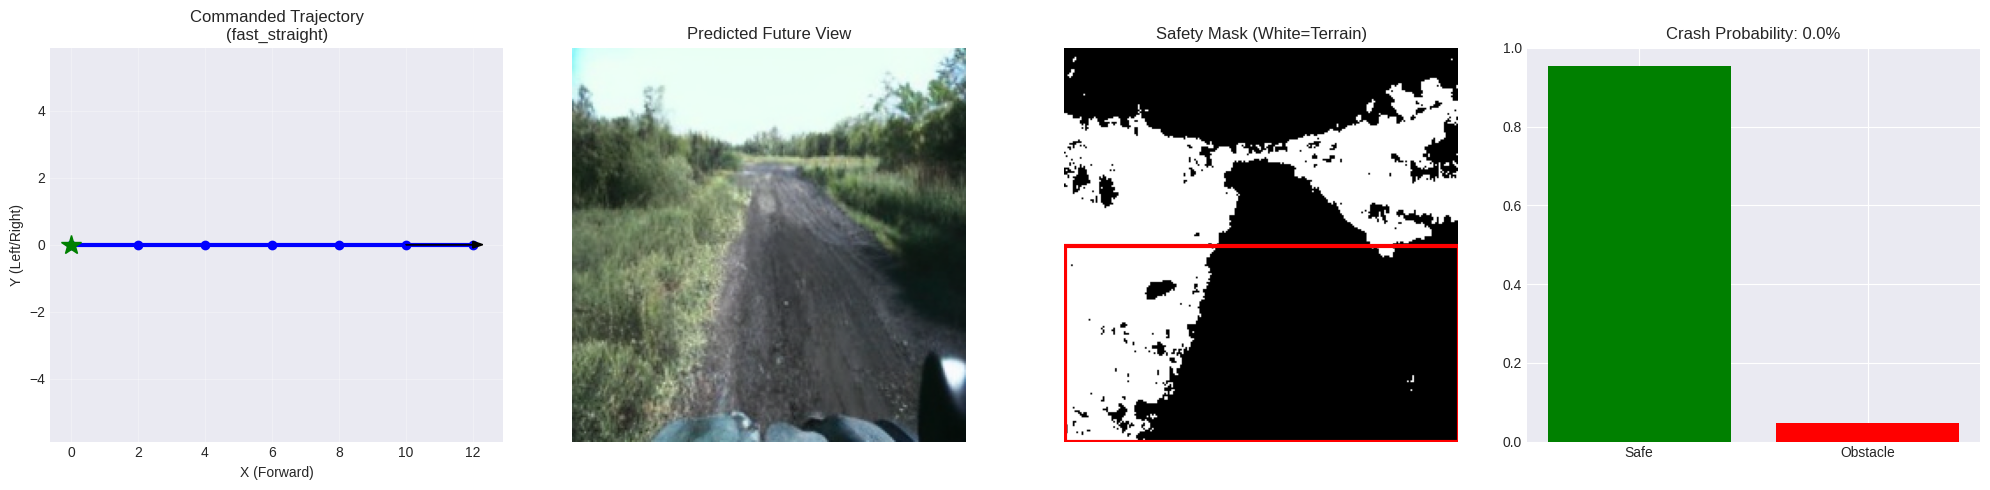

Testing gentle_turn_45...


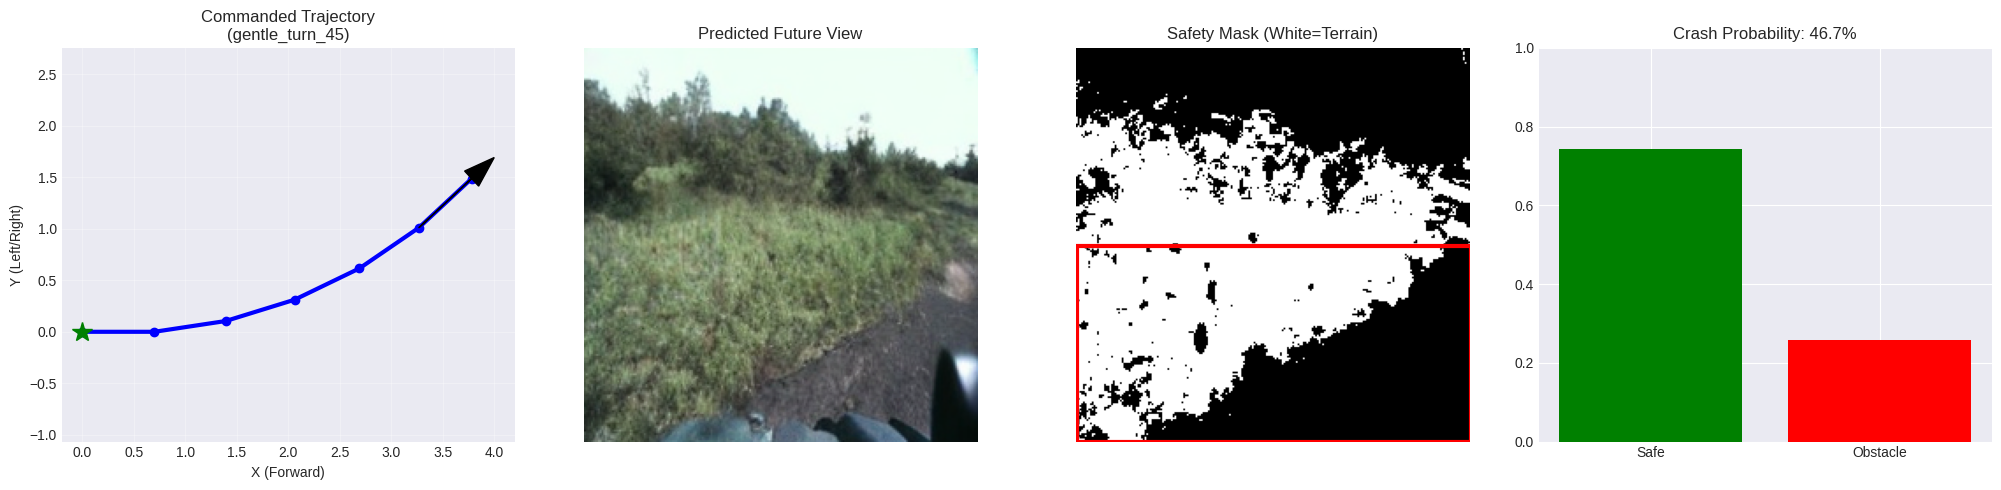

Testing sharp_turn_90...


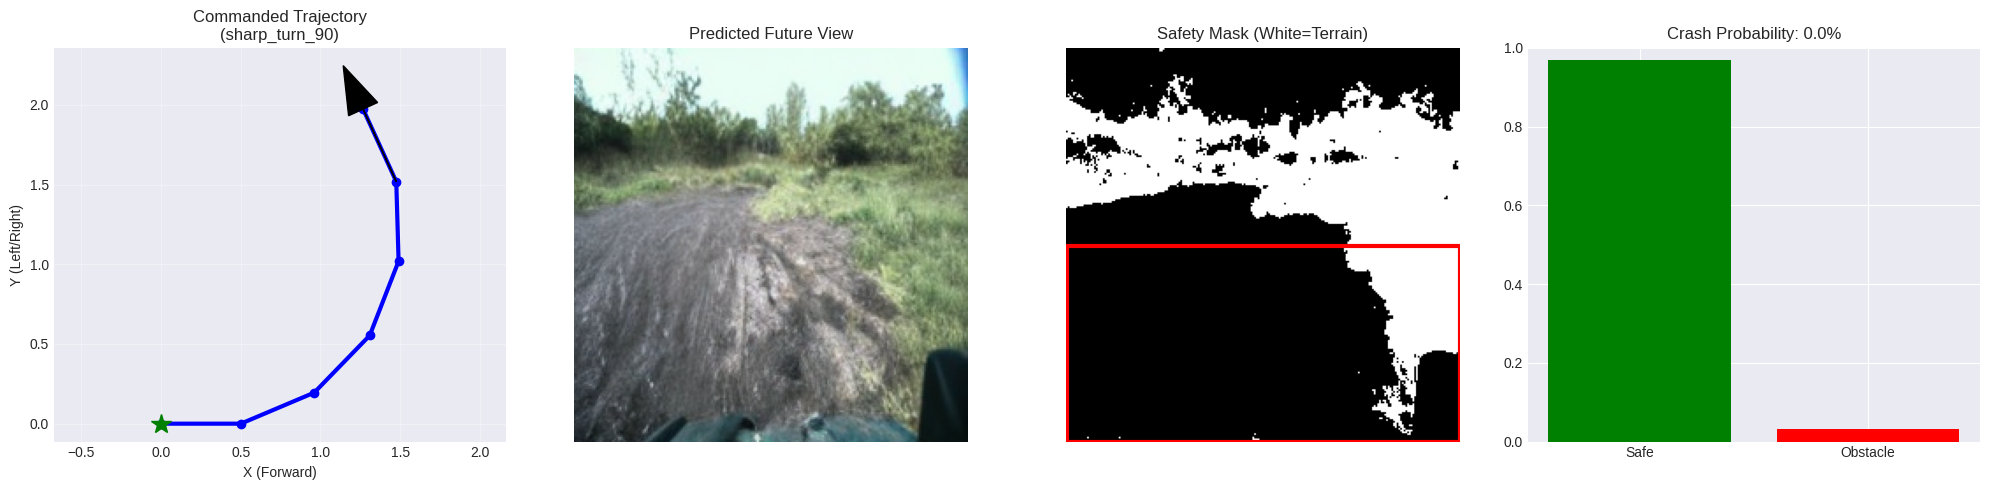

Testing wide_zigzag...


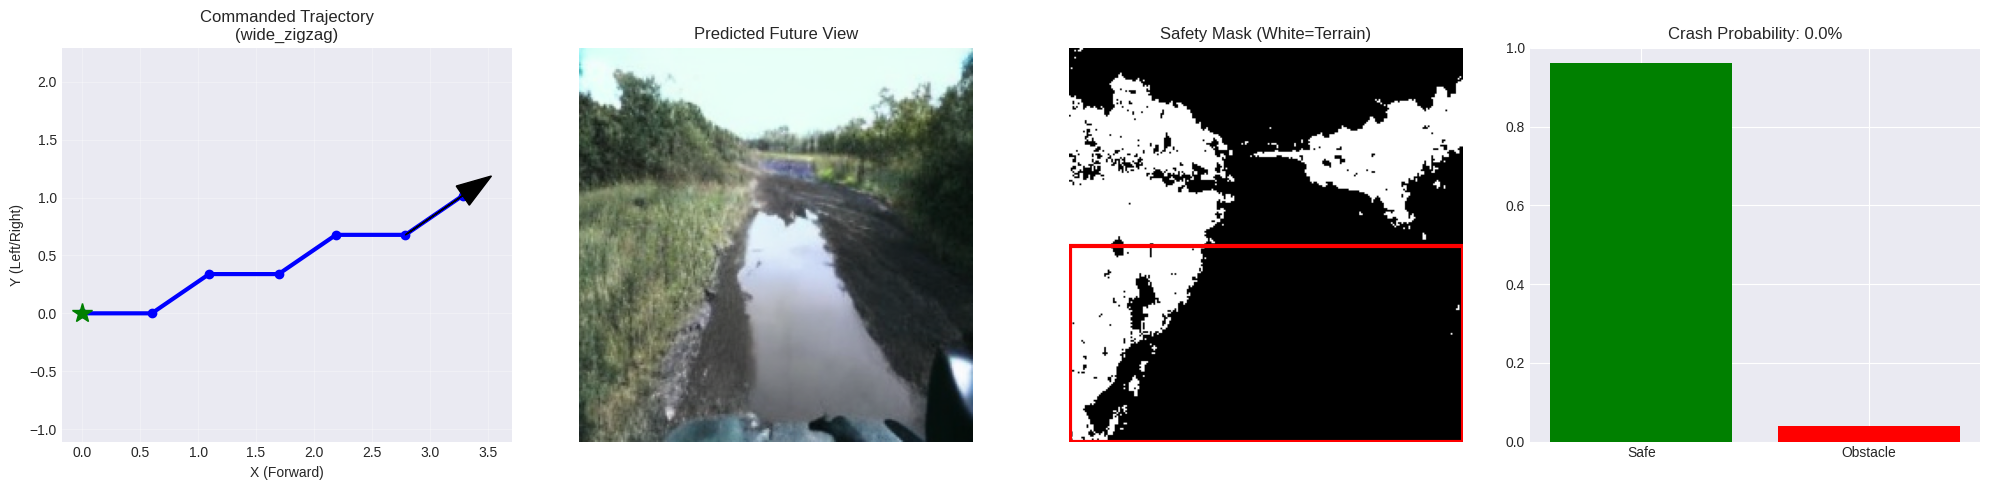

Testing weird_slide...


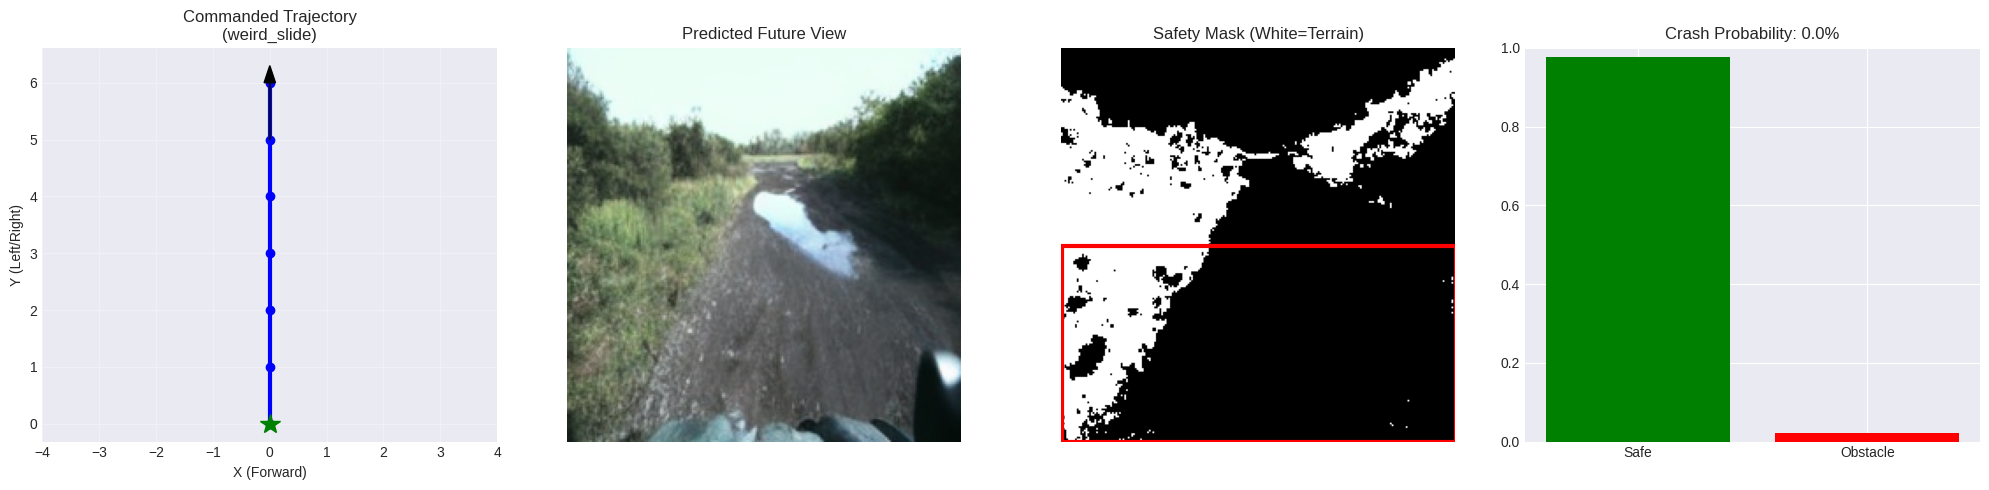

Testing Hard Slide Left...


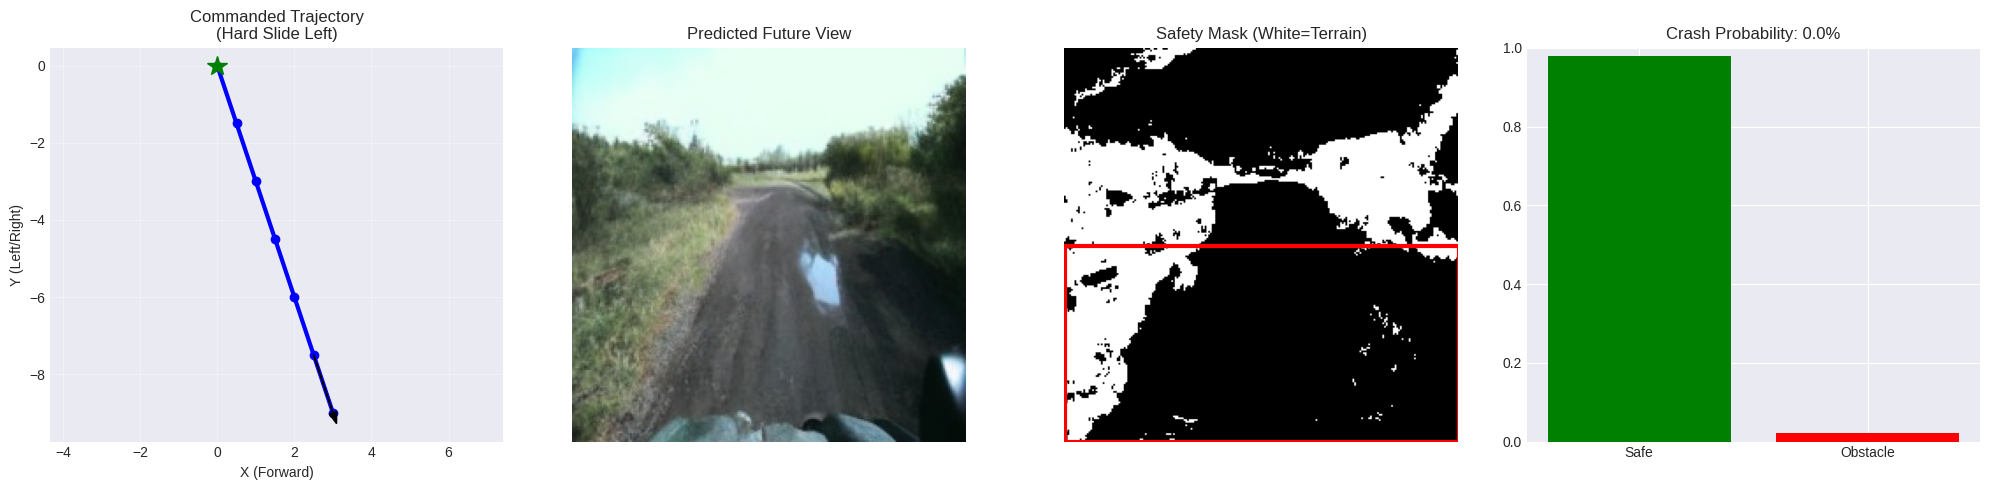

Testing Spin & Sprint...


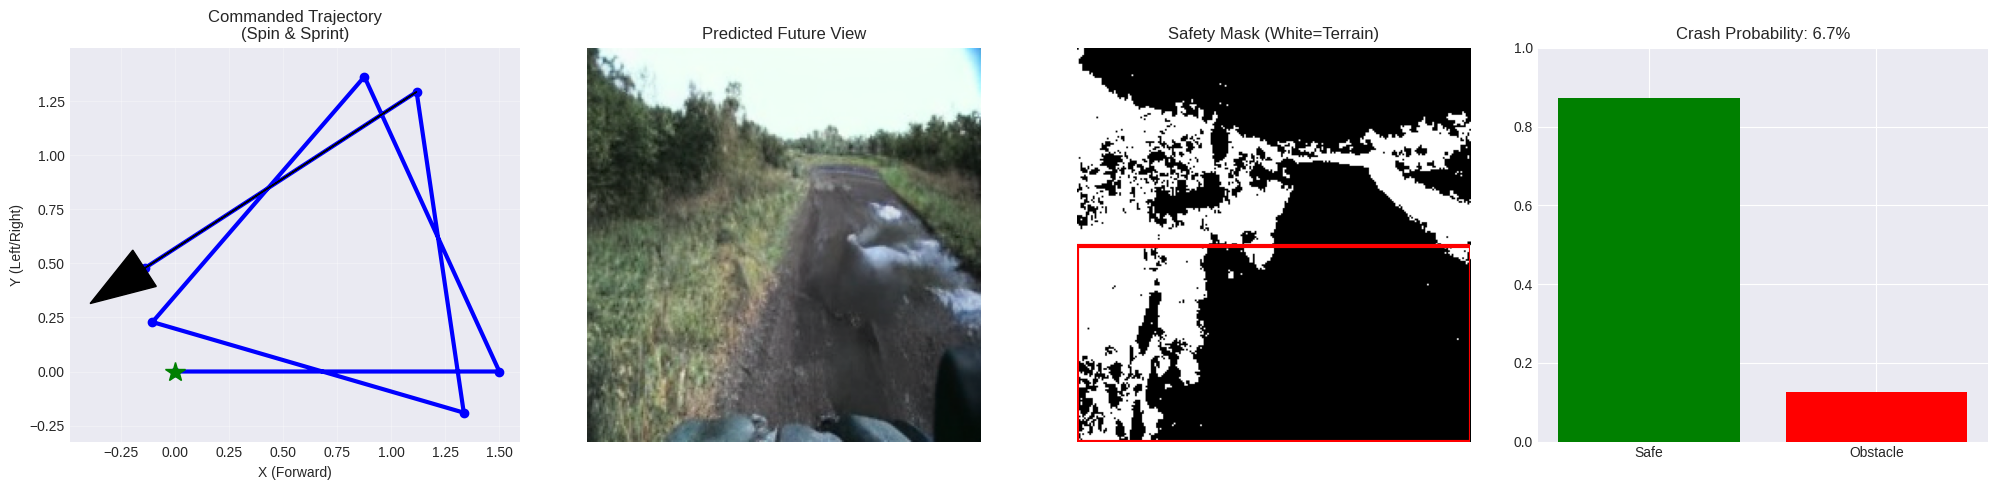

Testing Blind Reverse...


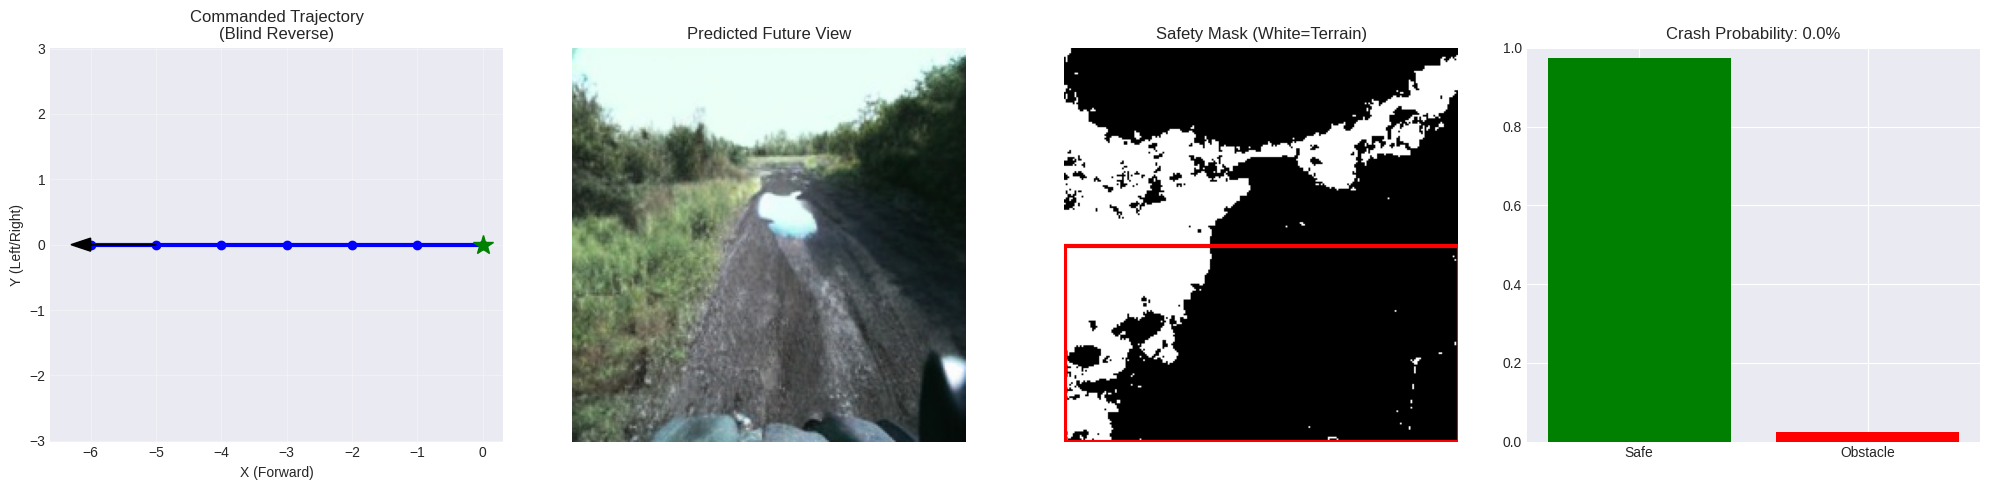

Testing Follow Road (Left)...


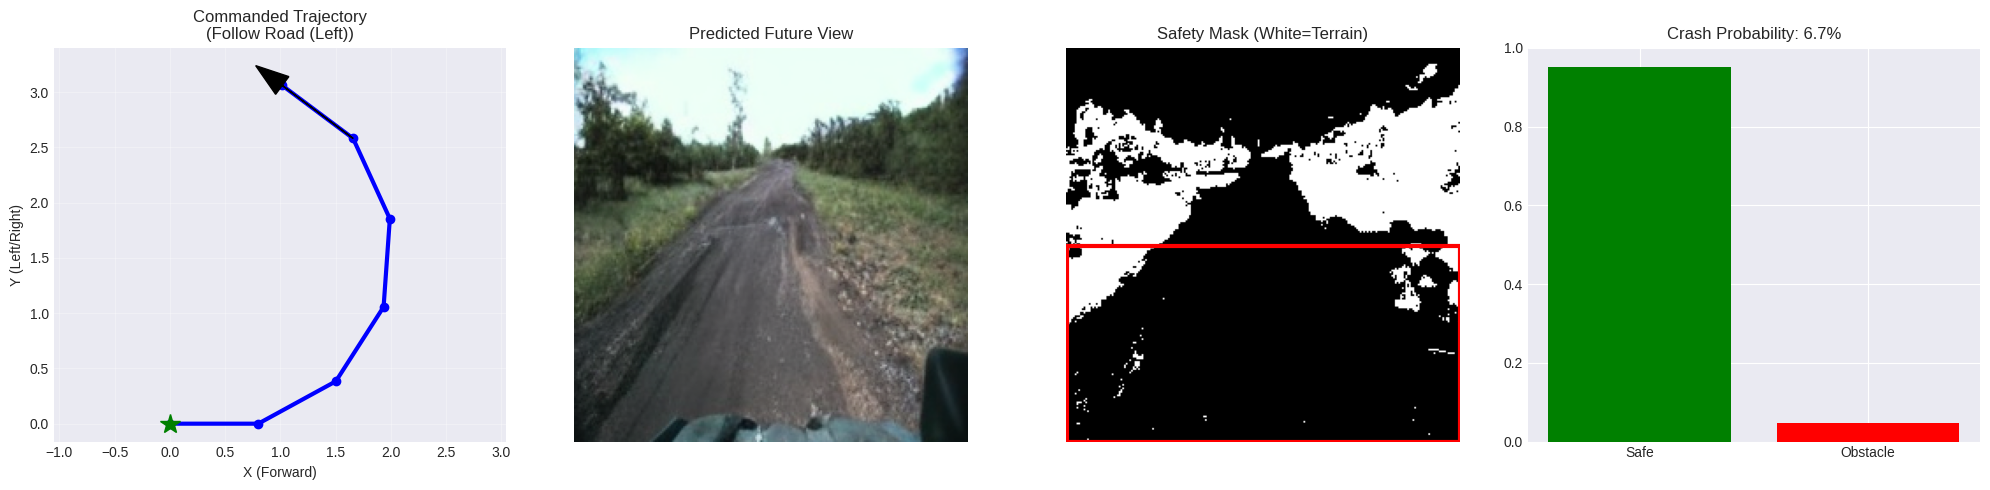

Testing Hard Right (Forest)...


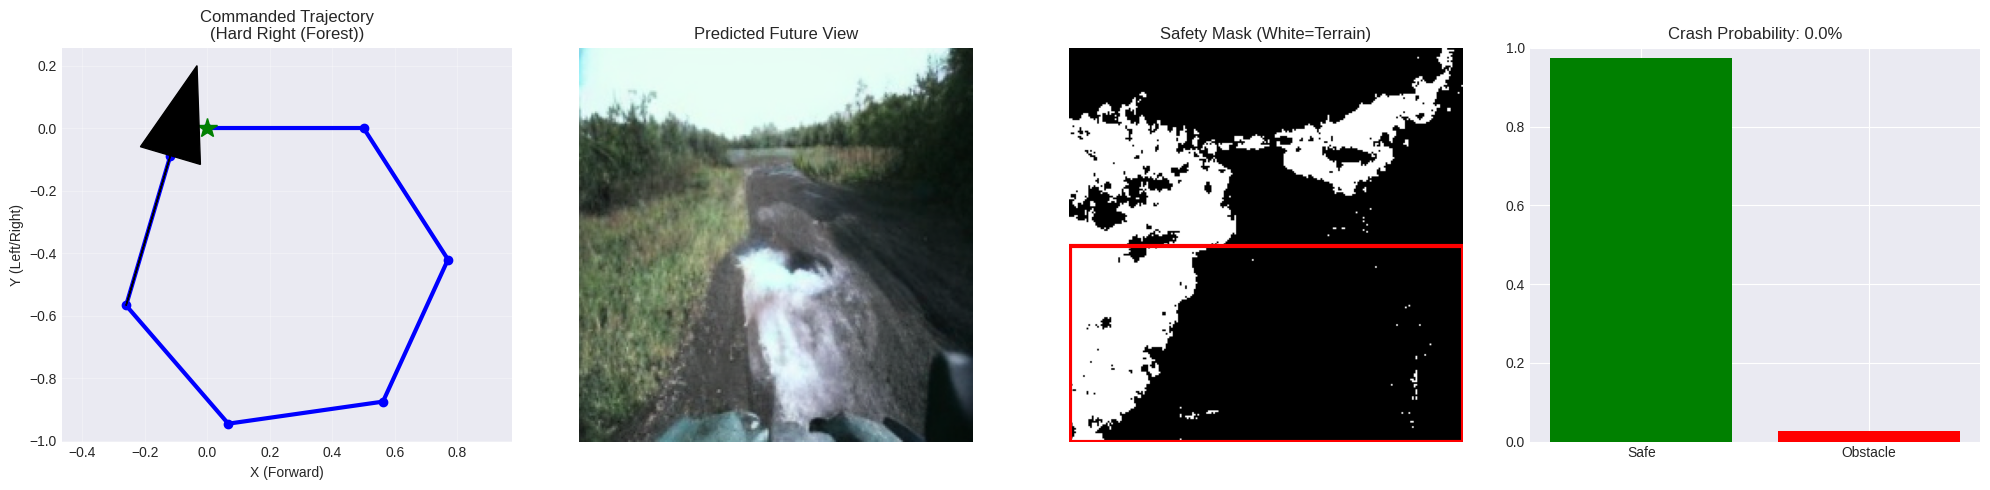

In [32]:
# Initialize Safety Monitor
safety_mon = SafetyMonitor()

print("🛡️ Experiment 3: Safety Classifier & Crash Prediction\n")

# 2. Test Sharp Turn (Should detect 'Green' obstacles)
# We create a trajectory that turns hard into the "Green" area of your image
# Adjust '0.8' to be a harder turn if needed to force it into the trees
scenarios = {
    'fast_straight': [[2.0, 0, 0]] * 6, 
    'gentle_turn_45': [[0.7, 0, 0.15]] * 6, 
    'sharp_turn_90': [[0.5, 0, 0.4]] * 6, 
    'wide_zigzag': [[0.6, 0, 0.6], [0.6, 0, -0.6]] * 3, 
    'weird_slide': [[0.0, 1.0, 0]] * 6,
    # 1. The "Sidewinder": Move Forward (0.5) but Slide HARD Left (-1.5) into the grass
    # This forces the camera physically sideways off the road.
    "Hard Slide Left": [[0.5, -1.5, 0.0]] * 6,
    # 2. The "Kamikaze": Maximum Forward (1.5) + Maximum Turn (2.0)
    # Moving so fast and turning so hard it can't find a road.
    "Spin & Sprint": [[1.5, 0, 2.0]] * 6,
    # 3. The "Reverse Crash": Go backwards (-1.0) blindly.
    # NWM often fails to generate clean backward paths and might hit "green" noise.
    "Blind Reverse": [[-1.0, 0, 0]] * 6,
    "Follow Road (Left)": [[0.8, 0, 0.5]] * 6,
    # 3. The Suicide Run: Hard Right into the forest
    "Hard Right (Forest)": [[0.5, 0, -1.0]] * 6
}

for name, traj in scenarios.items():
    print(f"Testing {name}...")
    result = safety_mon.calculate_crash_probability(sem_navigator, x_start, traj, num_samples=15)
    
    # PASS TRAJECTORY HERE -> 
    safety_mon.visualize_safety(result, name, traj)

# for name, traj in extreme_scenarios.items():
#     print(f"Testing {name}...")
#     result = safety_mon.calculate_crash_probability(sem_navigator, x_start, traj, num_samples=10)
#     safety_mon.visualize_safety(result, name)
#     print(f"  -> Crash Prob: {result['crash_probability']:.1%}\n")

# print("📊 SAFETY REPORT:")
# # print(f"Straight Crash Prob: {safe_result['crash_probability']:.1%}")
# print(f"Turning Crash Prob:  {unsafe_result['crash_probability']:.1%}")